In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import matplotlib.patches as mpatches
from find_best_K import find_best_K_F, generate_alpha_list, get_labels_at_K, find_best_K_chi
from hierarchical_clustering_invariant import * 
from sklearn.metrics import adjusted_rand_score
from palmerpenguins import load_penguins

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
from rpy2.robjects import numpy2ri, r
import warnings
import logging


warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("rpy2.rinterface_lib.callbacks").setLevel(logging.ERROR)

In [26]:
penguins_raw = load_penguins()
penguins_raw.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

In [27]:
penguins = penguins_raw[(penguins_raw["sex"] == "female") & (penguins_raw.notna().all(axis=1))& (penguins_raw["year"].between(2007,2008))]

In [28]:
labels = penguins["species"]
X = penguins[["flipper_length_mm","bill_length_mm"]].to_numpy()
np.random.seed(1) 
ind = np.random.choice(X.shape[0], 30, replace=False)
subset_mat = X[ind, :]
subset_labels = labels.iloc[ind]

In [29]:
def split_data_fission(X, gamma, seed=None):
    rng = np.random.default_rng(seed)
    n, p = X.shape
    sigma2 = X.var(ddof=1)
    W = rng.normal(loc=0, scale=np.sqrt(gamma* sigma2), size=(n,p))
    U = X + W
    V = X - W / gamma
    return U, V




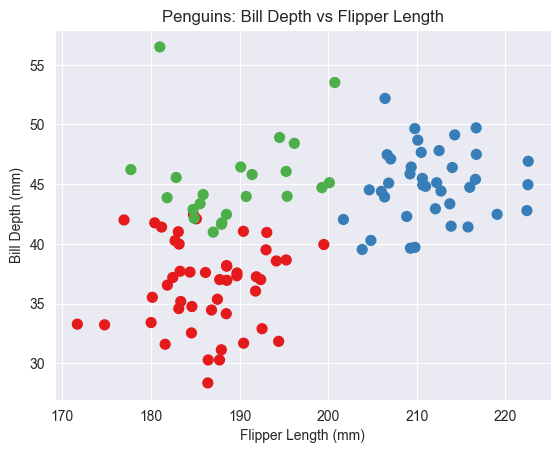

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
X_fit, X_inf = split_data_fission(X,0.001,seed=10)
species_unique = penguins["species"].unique()
palette = sns.color_palette("Set1", len(species_unique))
color_map = dict(zip(species_unique, palette))

plt.scatter(
    X_fit[:,0],
    X_fit[:,1],
    c=penguins["species"].map(color_map),
    s=50
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.title("Penguins: Bill Depth vs Flipper Length")
plt.show()

In [31]:
n = X.shape[0]
generate_alpha_list(n)

array([9.73075025e-03, 1.17574586e-02, 1.03879409e-02, 9.68287303e-03,
       8.20612893e-03, 4.47317381e-05, 3.52161452e-05, 5.59636435e-05,
       5.92476138e-05, 3.27427352e-05, 1.21189301e-07, 8.19688899e-08,
       8.78109336e-08, 1.41166081e-07, 1.36456203e-08, 1.60471090e-08,
       6.06243472e-09, 1.27291765e-07, 1.19164595e-07, 1.32871573e-07,
       1.49078161e-07, 1.22298558e-07, 7.19089092e-08, 1.19518617e-07,
       2.06946916e-08, 9.85365855e-08, 2.44370453e-08, 1.44012112e-07,
       8.09173723e-08, 6.49226529e-08, 4.25232718e-08, 1.18579182e-07,
       7.11136930e-08, 8.78690394e-08, 5.84925457e-09, 9.52110631e-08,
       9.43843990e-08, 9.51063829e-08, 1.43874701e-07, 1.04788939e-07,
       5.66923779e-08, 6.82607830e-08, 1.07148296e-07, 1.20324275e-08,
       1.02542592e-07, 1.03120259e-07, 3.44393834e-08, 2.22842004e-08,
       5.01146764e-08, 5.73195447e-08, 8.81320937e-08, 6.84949981e-08,
       1.50533910e-07, 1.82728527e-08, 3.42146820e-08, 2.71165356e-08,
      

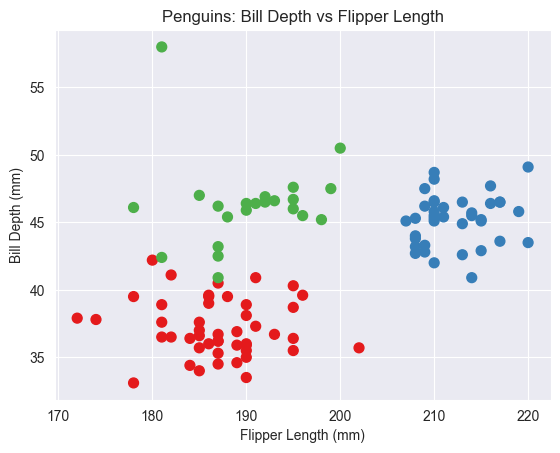

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

species_unique = penguins["species"].unique()
palette = sns.color_palette("Set1", len(species_unique))
color_map = dict(zip(species_unique, palette))

plt.scatter(
    penguins["flipper_length_mm"],
    penguins["bill_length_mm"],
    c=penguins["species"].map(color_map),
    s=50
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.title("Penguins: Bill Depth vs Flipper Length")
plt.show()

## p-values comparison

In [33]:
def get_labels_from_model(model):
    # Extract the cluster nodes
    clusters = model.K_clusters  # last merge level = final clusters

    # Compute total number of samples
    n = max(max(c.points) for c in clusters) + 1

    # Initialize label array
    labels_est = np.empty(n, dtype=int)

    # Assign labels
    for k, c in enumerate(clusters, start=1):
        for idx in c.points:
            labels_est[idx] = k

    return labels_est

In [34]:
random.seed(48)
model = AgglomerativeClustering(X,n_clusters=5, tau=0.1, linkage="average")
model.fit()
labels_est = get_labels_from_model(model)
# --- Define color map for clusters ---
n_labels = len(set(labels_est))
palette = sns.color_palette("Set2", n_labels)
color_map = dict(zip(sorted(set(labels_est)), palette))

# --- Define marker map for species ---
species_unique = penguins["species"].unique()
markers = ["o", "^", "s", "D", "v"] 
marker_map = dict(zip(species_unique, markers))

penguins = penguins.reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for species in species_unique:
    subset = penguins[penguins["species"] == species]
    plt.scatter(
        subset["flipper_length_mm"],
        subset["bill_length_mm"],
        c=[color_map[l] for l in labels_est[subset.index]],
        s=60,
        marker=marker_map[species],
        edgecolor="black",
        linewidth=0.4,
    )

plt.xlabel("Flipper length (mm)", fontsize=12)
plt.ylabel("Bill length (mm)", fontsize=12)
plt.title("Clustering Results", loc="left", fontsize=13, weight="bold")

cluster_patches = [
    mpatches.Patch(color=color_map[k], label=str(k)) for k in sorted(color_map)
]
cluster_legend = plt.legend(
    handles=cluster_patches,
    title="Clusters",
    title_fontsize=11,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.05, 0.6),
    frameon=False,
)

species_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker_map[s],
        color="w",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=8,
        linestyle="",
        label=s,
    )
    for s in species_unique
]
species_legend = plt.legend(
    handles=species_handles,
    title="Species",
    title_fontsize=11,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.05, 0.3),
    frameon=False,
)

plt.gca().add_artist(cluster_legend)

sns.despine()
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [147]:
pairs = combinations(np.arange(5), 2)
pair_list = []
pvals = []
for pair in pairs:
    print(pair)
    pair_list.append(pair)
    c1 = model.K_clusters[pair[0]]
    c2 = model.K_clusters[pair[1]]
    pval, _, _ = model.merge_inference_F_random_pair_grid(c1,c2, grid_width=120, ncoarse=30, ngrid=2000)
    pvals.append(pval)
    
rows = []
for pair_ind, pval in zip(pair_list, pvals):
    pair_plus_one = tuple(i + 1 for i in pair_ind)
    rows.append((pair_plus_one,pval))
df= pd.DataFrame(rows, columns=["Pair","pval"])

(np.int64(0), np.int64(1))
1e-05 120.0
(np.int64(0), np.int64(2))
1e-05 120.0
(np.int64(0), np.int64(3))
1e-05 104.94551916870404
(np.int64(0), np.int64(4))
1e-05 86.29422989943052
(np.int64(1), np.int64(2))
1e-05 120.0
(np.int64(1), np.int64(3))
1e-05 120.0
(np.int64(1), np.int64(4))
1e-05 120.0
(np.int64(2), np.int64(3))
1e-05 120.0
(np.int64(2), np.int64(4))
1e-05 76.68399925958843
(np.int64(3), np.int64(4))
1e-05 120.0


In [148]:
df

,Pair,pval
0,"(1, 2)",0.000073
1,"(1, 3)",0.173499
2,"(1, 4)",0.209348
3,"(1, 5)",0.053523
4,"(2, 3)",0.000000
5,"(2, 4)",0.000000
6,"(2, 5)",0.000000
7,"(3, 4)",0.545559
8,"(3, 5)",0.247402
9,"(4, 5)",0.570384


In [136]:
def compute_label(X, K=3, linkage = "average"):
    #ro.r('source("/home/judydw/RAC_invariant/r_functions.R")')
    ro.r('source("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/r_functions.R")')
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['X'] = ro.conversion.py2rpy(X)
    ro.globalenv['K_py'] = K
    ro.globalenv['link_py'] = linkage
    result = ro.r("get_labels(X, K_py, link_py)")
    return result

def compute_pval_gao(X, k1, k2, K=3, linkage = "average"):
    #ro.r('source("/home/judydw/RAC_invariant/r_functions.R")')
    ro.r('source("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/r_functions.R")')
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['X'] = ro.conversion.py2rpy(X)
    ro.globalenv['K_py'] = K
    ro.globalenv['k1_py'] = k2
    ro.globalenv['k2_py'] = k1
    ro.globalenv['link_py'] = linkage
    result = ro.r("get_pval(X, K_py, k1_py, k2_py, link_py)")
    return result

def get_pval_barber(X, K, k1, k2, linkage="average"):
    #ro.r('source("/home/judydw/RAC_invariant/r_functions.R")')
    ro.r('source("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/r_functions.R")')
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['X'] = ro.conversion.py2rpy(X)
    ro.globalenv['k1_py'] = k2
    ro.globalenv['k2_py'] = k1
    ro.globalenv['K_py'] = K
    ro.globalenv['link_py'] = linkage
    result = ro.r("get_barber_pval_pair(X, K_py, k1_py, k2_py, link_py)")
    return result

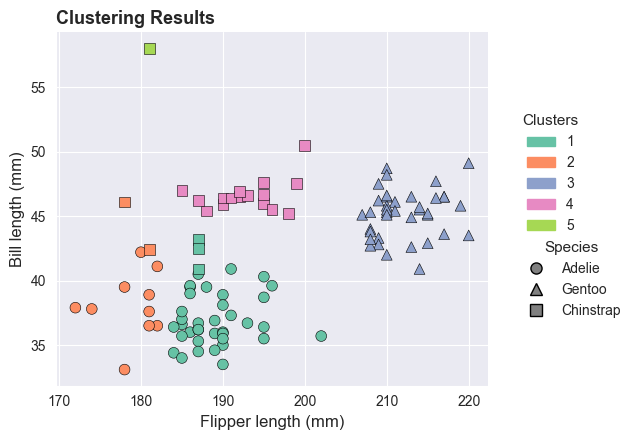

In [146]:
labels_est = np.array(compute_label(X, K=5, linkage = "average"))
# --- Define color map for clusters ---
n_labels = len(set(labels_est))
palette = sns.color_palette("Set2", n_labels)
color_map = dict(zip(sorted(set(labels_est)), palette))

# --- Define marker map for species ---
species_unique = penguins["species"].unique()
markers = ["o", "^", "s", "D", "v"] 
marker_map = dict(zip(species_unique, markers))

penguins = penguins.reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for species in species_unique:
    subset = penguins[penguins["species"] == species]
    plt.scatter(
        subset["flipper_length_mm"],
        subset["bill_length_mm"],
        c=[color_map[l] for l in labels_est[subset.index]],
        s=60,
        marker=marker_map[species],
        edgecolor="black",
        linewidth=0.4,
    )

plt.xlabel("Flipper length (mm)", fontsize=12)
plt.ylabel("Bill length (mm)", fontsize=12)
plt.title("Clustering Results", loc="left", fontsize=13, weight="bold")

cluster_patches = [
    mpatches.Patch(color=color_map[k], label=str(k)) for k in sorted(color_map)
]
cluster_legend = plt.legend(
    handles=cluster_patches,
    title="Clusters",
    title_fontsize=11,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.05, 0.6),
    frameon=False,
)

species_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker_map[s],
        color="w",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=8,
        linestyle="",
        label=s,
    )
    for s in species_unique
]
species_legend = plt.legend(
    handles=species_handles,
    title="Species",
    title_fontsize=11,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.05, 0.3),
    frameon=False,
)

plt.gca().add_artist(cluster_legend)

sns.despine()
plt.tight_layout()
plt.show()

In [135]:
pairs = combinations(np.arange(5), 2)
pair_list = []
pvals_g = []
pvals_b = []
for pair in pairs:
    print(pair)
    pair_plus_one = tuple(i + 1 for i in pair)
    k1 = int(pair_plus_one[0])
    k2 = int(pair_plus_one[1])
    pair_list.append(pair_plus_one)
    pval_b = get_pval_barber(X,5, k1, k2)
    pvals_b.append(pval_b)
    pval_g = compute_pval_gao(X, k1, k2, 5)
    pvals_g.append(pval_g)
    
rows = []
for pair_ind, pval_g, pval_b in zip(pair_list, pvals_g, pvals_b):
    rows.append((pair_ind,pval_g, pval_b))
df= pd.DataFrame(rows, columns=["Pair","pval_Gao","pval_Barber"])
df

(np.int64(0), np.int64(1))
(np.int64(0), np.int64(2))
(np.int64(0), np.int64(3))
(np.int64(0), np.int64(4))
(np.int64(1), np.int64(2))
(np.int64(1), np.int64(3))
(np.int64(1), np.int64(4))
(np.int64(2), np.int64(3))
(np.int64(2), np.int64(4))
(np.int64(3), np.int64(4))


,Pair,pval_Gao,pval_Barber
0,"(1, 2)",[0.618817017068719],[0.10044851125156577]
1,"(1, 3)",[2.829470083103708e-13],[0.002152362526217584]
2,"(1, 4)",[0.735246983852718],[0.25213445285467806]
3,"(1, 5)",[0.24886913333015626],[0.04120823622065013]
4,"(2, 3)",[0.08837780125149178],[0.025836109307936766]
5,"(2, 4)",[0.32440630715160784],[0.12312331175934918]
6,"(2, 5)",[0.46447108250189123],[0.33215738289192176]
7,"(3, 4)",[6.618149112727882e-06],[0.0030398051749769726]
8,"(3, 5)",[0.05383152514852819],[5.9066482886743204e-08]
9,"(4, 5)",[0.34624216864668544],[0.12457505331242175]


## Choose K

In [5]:
species_unique_sub = subset_labels.unique()
palette_sub = sns.color_palette("Set1", len(species_unique_sub))
color_map = dict(zip(species_unique_sub, palette_sub))
plt.scatter(subset_mat[:,0],subset_mat[:,1],c=subset_labels.map(color_map))

NameError: name 'sns' is not defined

In [7]:
#sd_est = np.cov(subset_mat, rowvar=False)
sd_est = np.std(subset_mat, ddof = 0)

In [9]:
random.seed(48)
n = X.shape[0]
total_alpha = 0.05
#alpha_list = np.full(n - 1, total_alpha / (n - 1))
alpha_list = generate_alpha_list(n,total_alpha)
Khat, _, _, labels_est =find_best_K_F(X, 0.1, alpha_list,total_alpha)
#Khat, _, _ = find_best_K_chi(subset_mat, sigma = sd_est, tau=0.1, alpha_list=alpha_list, total_alpha=total_alpha)

KeyboardInterrupt: 

In [ ]:
Khat

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# unique groups for original labels
species_unique_sub = subset_labels.unique()
shapes = ["^", "v", "P", "X"]  # enough shapes for up to 7 classes
shape_map = dict(zip(species_unique_sub, shapes))

# unique groups for new clustering
cluster_unique = np.unique(labels_est)
palette_sub = sns.color_palette("Set1", len(cluster_unique))
color_map = dict(zip(cluster_unique, palette_sub))

# plotting
plt.figure(figsize=(6,5))
for sp in species_unique_sub:
    idx = subset_labels == sp
    plt.scatter(
        subset_mat[idx, 0],
        subset_mat[idx, 1],
        c=[color_map[l] for l in labels_est[idx]],  # color by cluster
        marker=shape_map[sp],                      # shape by original label
        s=60,
        edgecolor="black",
        alpha=0.8,
        label=str(sp)
    )

plt.legend(title="Original labels")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Color = estimated cluster, Shape = original label")
plt.tight_layout()
plt.show()


NameError: name 'labels_est' is not defined

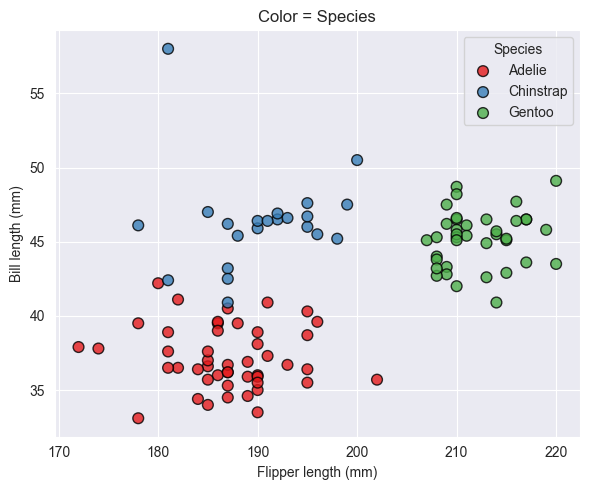

In [11]:
# unique species (original labels)
species_unique = np.unique(labels)
palette = sns.color_palette("Set1", len(species_unique))

# color map by original label
color_map = dict(zip(species_unique, palette))

# plotting full dataset
plt.figure(figsize=(6, 5))
for sp in species_unique:
    idx = labels == sp
    plt.scatter(
        X[idx, 0],
        X[idx, 1],
        c=[color_map[sp]] * np.sum(idx),  # color by original label
        s=60,
        edgecolor="black",
        alpha=0.8,
        label=str(sp)
    )

plt.legend(title="Species")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Bill length (mm)")
plt.title("Color = Species")
plt.tight_layout()
plt.show()


1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 83.36010350725451
1e-05 160.12009569483064
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 73.96732552926525
1e-05 73.39846456062072
1e-05 71.95120944090255
1e-05 200.0
1e-05 78.65623173007778
1e-05 60.533247112372635
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 105.57543741022971
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 170.38059354698765
1e-05 86.23535259495407
1e-05 129.82061596129876
1e-05 72.58911532649529
1e-05 200.0
1e-05 166.5276529110837
1e-05 78.44853255119503
1e-05 76.52159194005353
1e-05 192.64429390087943
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 100.5600279627249
1e-05 200.0
1e-05 184.42454977209854
1e-05 180.29440226604032
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 153.60925220715882
1e-05 200.0
1e-05 200.0
1e-05 169.6856460609864
1e-05 94.74618064132659
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 200.0
1e-05 195.16366435929743
1e-05 110.95456879

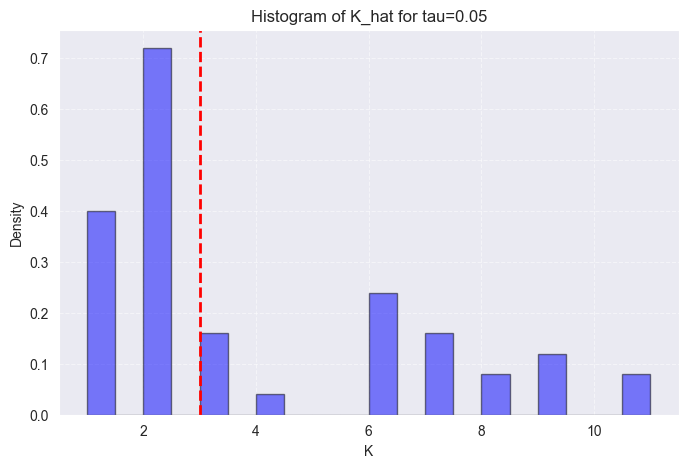

<bound method Counter.most_common of Counter({2: 18, 1: 10, 6: 6, 3: 4, 7: 4, 9: 3, 11: 2, 8: 2, 4: 1})>

In [5]:
random.seed(0)
n=30
true_K=3
total_alpha = 0.05
num_trials = 50
Ks = []
alpha_list = generate_alpha_list(n) #np.full(n - 1, total_alpha / (n - 1))
for _ in range(num_trials):
    K,_,_,_ = find_best_K_F(subset_mat, tau=0.1, alpha_list=alpha_list)
    #K,_,_ = find_best_K_chi(subset_mat, sigma = sd_est, tau=0.1, alpha_list=alpha_list)
    Ks.append(K)
plt.figure(figsize=(8, 5))
plt.hist(Ks, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="K hat")
plt.axvline(x=true_K, color='red', linestyle='--', linewidth=2, label=f"True K = {true_K}")
plt.xlabel("K")
plt.ylabel("Density")
plt.title("Histogram of K_hat for tau=0.05")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
from collections import Counter
counter = Counter(Ks)

counter.most_common

In [35]:
import seaborn as sns
def clusters_to_labels(clusters, n_samples):
    labels = np.empty(n_samples, dtype=int)
    for cid, cluster in enumerate(clusters):
        for idx in cluster.points:
            labels[idx] = cid
    return labels

def compute_stability(X,K, linkage = "complete",tau =0.1, n_runs=100, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    labels_list = []

    # multiple runs with different seeds
    for _ in range(n_runs):
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K, linkage=linkage)
        model.fit()
        clusters = model.K_clusters
        labels = clusters_to_labels(clusters, X.shape[0])
        labels_list.append(np.asarray(labels))

    labels_list = np.stack(labels_list, axis=0)  # shape (n_runs, n_samples)
    n_runs, n_samples = labels_list.shape
    
    # ---------- 1. ARI ----------
    ari_matrix = np.zeros((n_runs, n_runs))
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            ari = adjusted_rand_score(labels_list[i], labels_list[j]) #ari between different clustering results
            ari_matrix[i, j] = ari_matrix[j, i] = ari
    mean_ari = np.mean(ari_matrix[np.triu_indices(n_runs, k=1)])

    # ---------- 2. Pairwise co-occurrence ----------
    cooccurrence = np.zeros((n_samples, n_samples))
    for r in range(n_runs):
        labels_r = labels_list[r]
        for k in np.unique(labels_r):
            idx = np.where(labels_r == k)[0]
            cooccurrence[np.ix_(idx, idx)] += 1
    cooccurrence /= n_runs  # convert to proportion

    # Per-sample average co-occurrence (how stably each point clusters with others)
    mean_cooccurrence_per_sample = np.mean(cooccurrence, axis=1)
    
    sns.heatmap(ari_matrix, cmap="viridis", vmin=0, vmax=1, square=True)
    plt.title("ARI between runs")
    plt.show()
    
    sns.clustermap(cooccurrence,cmap="viridis",row_cluster=True,col_cluster=True,figsize=(8,8))
    plt.title("Reordered Pairwise Co-occurrence Matrix")
    plt.show()
    
    sns.heatmap(cooccurrence, cmap= "viridis")
    plt.title("Pairwise Co-occurrence Matrix")
    plt.show()

    return {
        "mean_ARI": mean_ari,
        "ARI_matrix": ari_matrix,
        "cooccurrence": cooccurrence,
        "mean_cooccurrence_per_sample": mean_cooccurrence_per_sample,
    }

In [49]:
from scipy.cluster.hierarchy import linkage as scipy_linkage, fcluster
def resample_data_indices(n, p=0.67, replacement=False, seed=None):
    rng = np.random.default_rng(seed)

    if replacement:   # bootstrap
        idx = rng.choice(n, size=n, replace=True)
    else:             # subsample
        k = int(np.floor(p * n))
        idx = rng.choice(n, size=k, replace=False)

    return idx
def compute_stability_sampled(
    X, K,
    p=0.67,
    replacement=False,
    linkage="complete",
    tau=0.1,
    n_runs=100,
    random_state=None
):
    n = X.shape[0]
    labels_full_runs = []

    if random_state is not None:
        np.random.seed(random_state)

    for t in range(n_runs):
        idx = resample_data_indices(n, p, replacement, seed=t)

        X_sub = X[idx]

        #model = AgglomerativeClustering(X_sub, tau=tau, n_clusters=K, linkage=linkage)
        #model.fit()

        #clusters = model.K_clusters
        #labels_sub = clusters_to_labels(clusters, X_sub.shape[0])
        Z = scipy_linkage(X_sub, method=linkage)
        labels_sub = fcluster(Z, K, criterion="maxclust") - 1

        labels_full = np.full(n, -1) 
        labels_full[idx] = labels_sub

        labels_full_runs.append(labels_full)

    labels_full_runs = np.stack(labels_full_runs, axis=0)  # shape: (n_runs, n)


    ari_matrix = np.zeros((n_runs, n_runs))
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            mask = (labels_full_runs[i] != -1) & (labels_full_runs[j] != -1)
            if np.sum(mask) > 1:
                ari = adjusted_rand_score(labels_full_runs[i][mask], labels_full_runs[j][mask])
            else:
                ari = 0
            ari_matrix[i, j] = ari_matrix[j, i] = ari

    mean_ari = np.mean(ari_matrix[np.triu_indices(n_runs, k=1)])

    cooccurrence = np.zeros((n, n))
    counts = np.zeros((n, n)) 

    for r in range(n_runs):
        labels_r = labels_full_runs[r]

        valid_idx = np.where(labels_r != -1)[0]
        counts[np.ix_(valid_idx, valid_idx)] += 1
        for lab in np.unique(labels_r[valid_idx]):
            idxs = valid_idx[labels_r[valid_idx] == lab]
            cooccurrence[np.ix_(idxs, idxs)] += 1

    cooccurrence = np.divide(cooccurrence, counts, where=counts > 0)
    cooccurrence[np.isnan(cooccurrence)] = 0
    cooccurrence[np.isinf(cooccurrence)] = 0
    
    valid = np.sum(counts, axis=0) > 0
    coocc_valid = cooccurrence[np.ix_(valid, valid)]

    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # Visualization
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    sns.heatmap(ari_matrix, cmap="viridis", vmin=0, vmax=1, square=True)
    plt.title("ARI between runs")
    plt.show()
    sns.heatmap(cooccurrence, cmap="viridis")
    plt.title("Pairwise Co-occurrence Matrix")
    plt.show()

    sns.clustermap(coocc_valid, cmap="viridis", figsize=(8,8))
    plt.title("Reordered Pairwise Co-occurrence Matrix")
    plt.show()


    return {
        "mean_ARI": mean_ari,
        "ARI_matrix": ari_matrix,
        "cooccurrence": cooccurrence,
        "runs": labels_full_runs,
    }

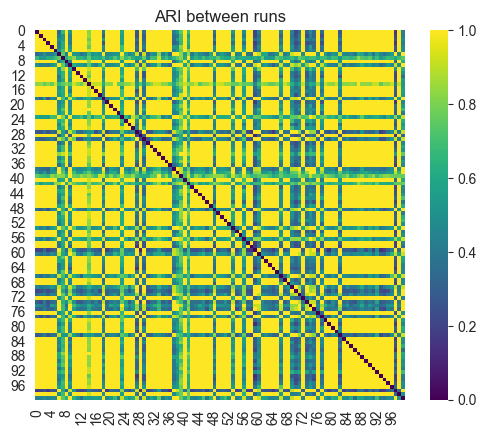

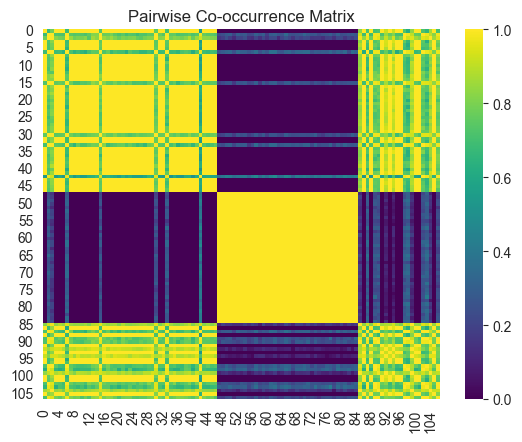

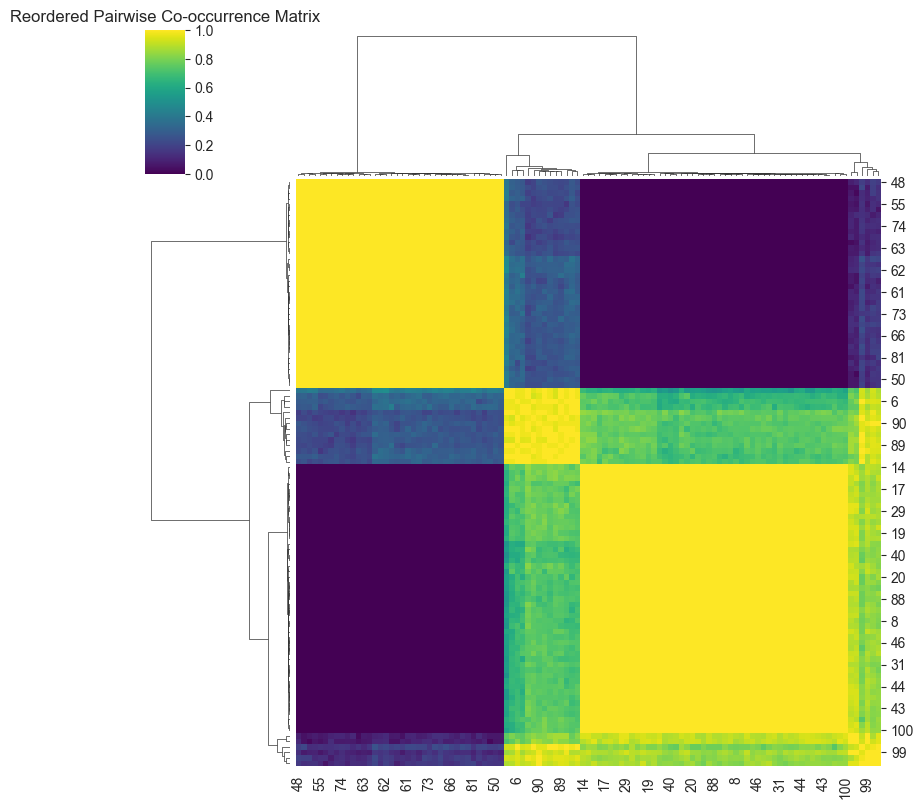

{'mean_ARI': np.float64(0.7789471294931948),
 'ARI_matrix': array([[0.        , 1.        , 1.        , ..., 0.17004525, 1.        ,
         0.43296637],
        [1.        , 0.        , 1.        , ..., 0.1939314 , 1.        ,
         0.43296637],
        [1.        , 1.        , 0.        , ..., 0.24358314, 1.        ,
         0.49130107],
        ...,
        [0.17004525, 0.1939314 , 0.24358314, ..., 0.        , 0.31186753,
         1.        ],
        [1.        , 1.        , 1.        , ..., 0.31186753, 0.        ,
         0.50892518],
        [0.43296637, 0.43296637, 0.49130107, ..., 1.        , 0.50892518,
         0.        ]]),
 'cooccurrence': array([[1.        , 0.67346939, 0.77777778, ..., 0.85714286, 1.        ,
         0.70454545],
        [0.67346939, 1.        , 1.        , ..., 0.9047619 , 0.81578947,
         0.98      ],
        [0.77777778, 1.        , 1.        , ..., 1.        , 0.85365854,
         0.95238095],
        ...,
        [0.85714286, 0.9047619 , 

In [50]:
compute_stability_sampled(X, 2,p=0.67,replacement=False,linkage="complete",tau=0.1,n_runs=100,random_state=None )

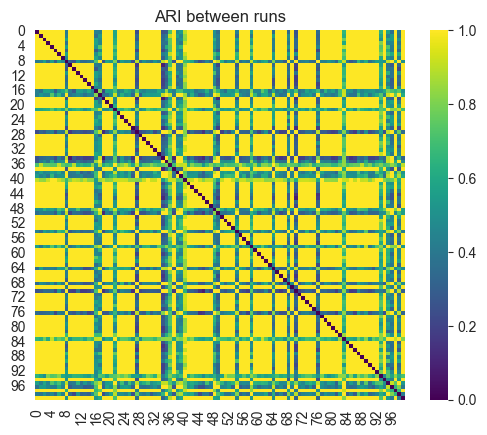

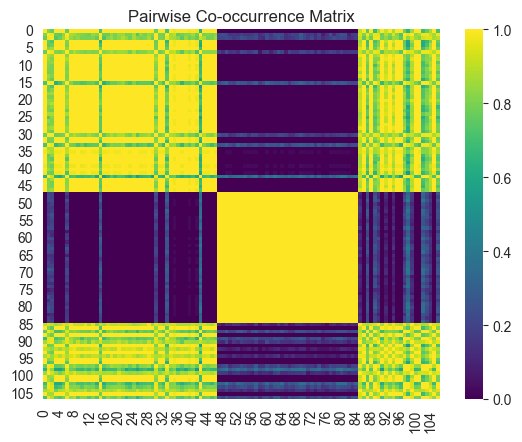

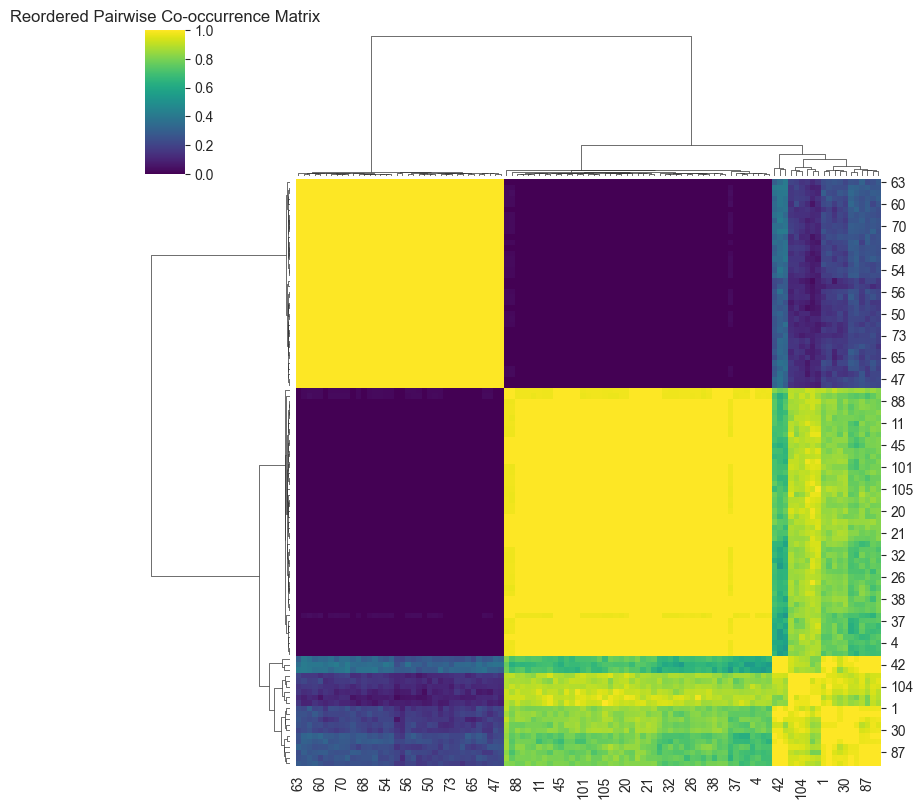

{'mean_ARI': np.float64(0.8040161351997455),
 'ARI_matrix': array([[0.        , 1.        , 1.        , ..., 1.        , 0.40957886,
         1.        ],
        [1.        , 0.        , 1.        , ..., 1.        , 0.3928113 ,
         1.        ],
        [1.        , 1.        , 0.        , ..., 1.        , 0.49854397,
         1.        ],
        ...,
        [1.        , 1.        , 1.        , ..., 0.        , 0.64636071,
         1.        ],
        [0.40957886, 0.3928113 , 0.49854397, ..., 0.64636071, 0.        ,
         0.40337284],
        [1.        , 1.        , 1.        , ..., 1.        , 0.40337284,
         0.        ]]),
 'cooccurrence': array([[1.        , 0.81632653, 0.76595745, ..., 0.86666667, 1.        ,
         0.71111111],
        [0.81632653, 1.        , 0.97368421, ..., 0.91428571, 0.86111111,
         0.97619048],
        [0.76595745, 0.97368421, 1.        , ..., 0.94871795, 0.86111111,
         0.8974359 ],
        ...,
        [0.86666667, 0.91428571, 

In [51]:
compute_stability_sampled(X, 2,p=0.67,replacement=True,linkage="complete",tau=0.1,n_runs=100,random_state=None )

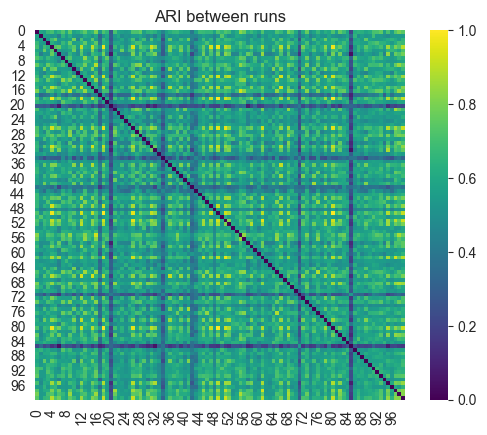

/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


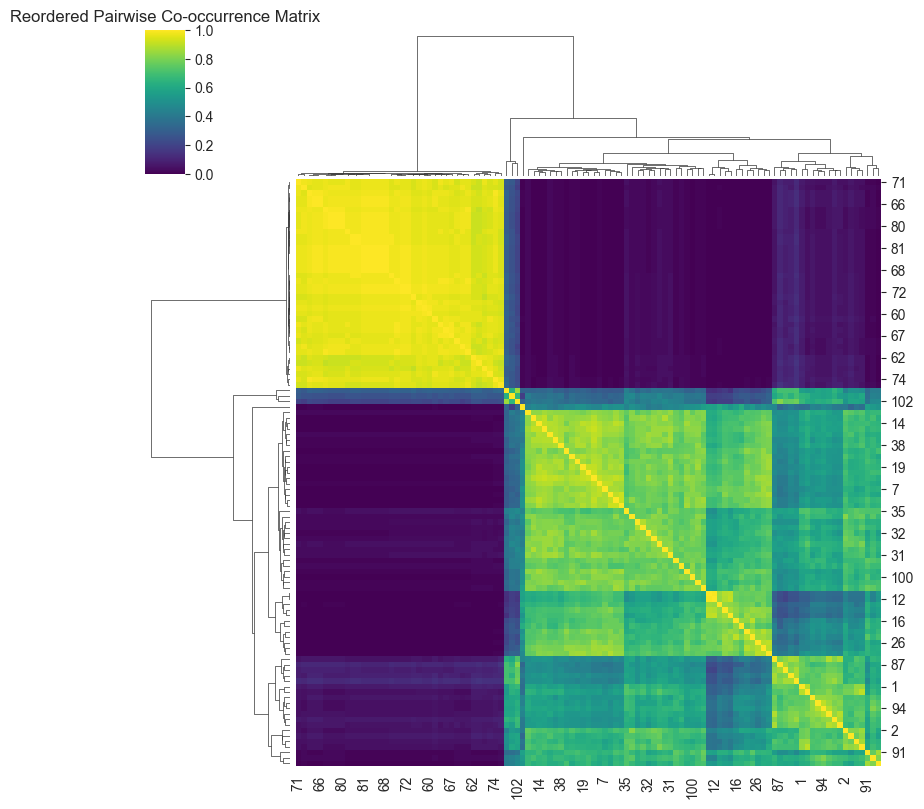

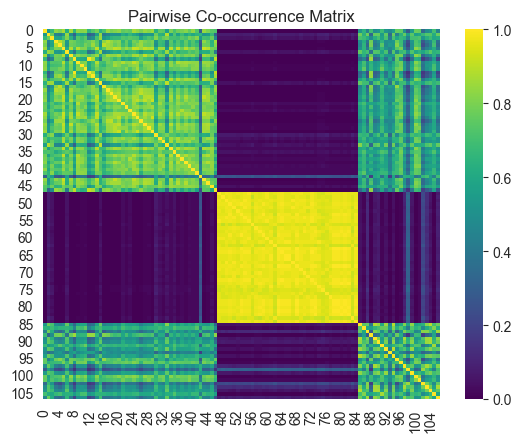

{'mean_ARI': np.float64(0.5689416115864153),
 'ARI_matrix': array([[0.        , 0.58751721, 0.55911017, ..., 0.72706687, 0.78919837,
         0.74134851],
        [0.58751721, 0.        , 0.56958327, ..., 0.54299662, 0.53914511,
         0.54634743],
        [0.55911017, 0.56958327, 0.        , ..., 0.60851157, 0.55091294,
         0.65371547],
        ...,
        [0.72706687, 0.54299662, 0.60851157, ..., 0.        , 0.77629801,
         0.82053895],
        [0.78919837, 0.53914511, 0.55091294, ..., 0.77629801, 0.        ,
         0.81343586],
        [0.74134851, 0.54634743, 0.65371547, ..., 0.82053895, 0.81343586,
         0.        ]]),
 'cooccurrence': array([[1.  , 0.53, 0.67, ..., 0.52, 0.7 , 0.45],
        [0.53, 1.  , 0.77, ..., 0.73, 0.62, 0.77],
        [0.67, 0.77, 1.  , ..., 0.68, 0.6 , 0.62],
        ...,
        [0.52, 0.73, 0.68, ..., 1.  , 0.67, 0.75],
        [0.7 , 0.62, 0.6 , ..., 0.67, 1.  , 0.59],
        [0.45, 0.77, 0.62, ..., 0.75, 0.59, 1.  ]]),
 'mean_cooccu

In [51]:
compute_stability(X, 3)

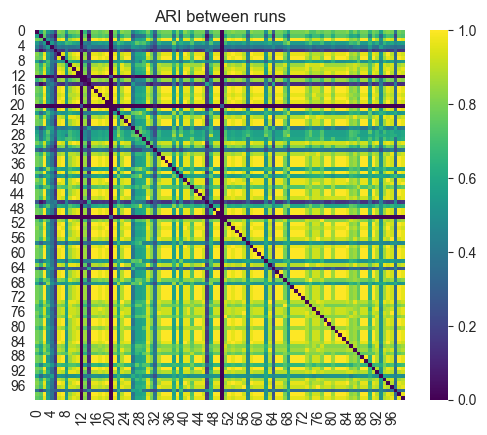

/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


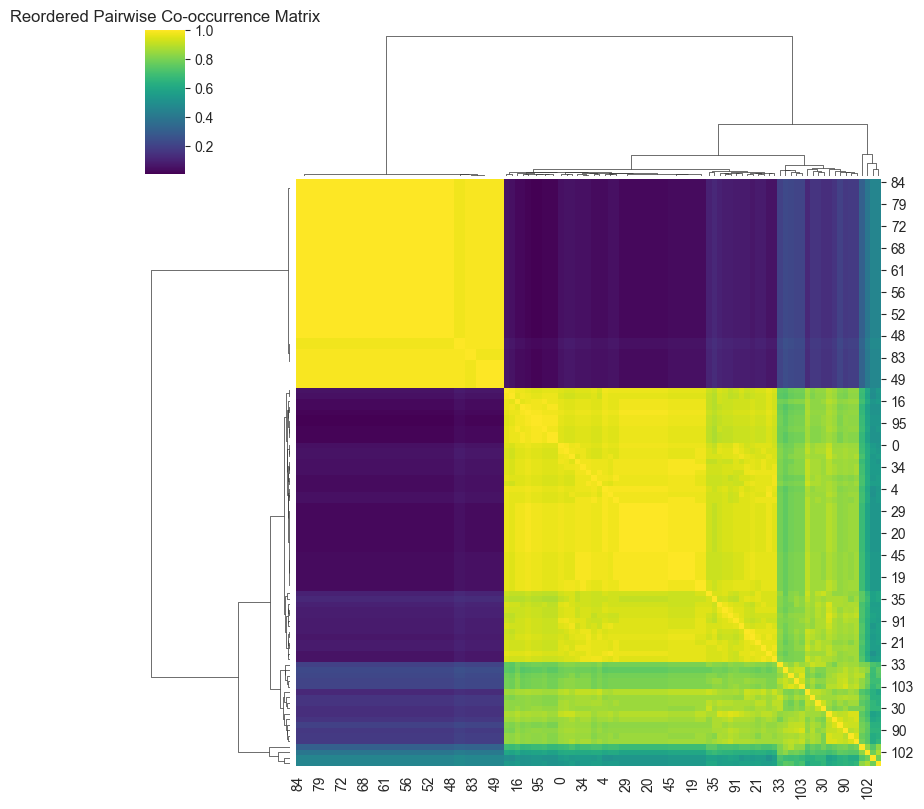

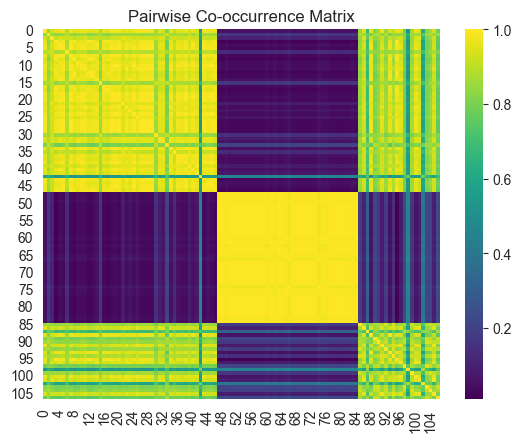

{'mean_ARI': np.float64(0.6869220613659586),
 'ARI_matrix': array([[0.        , 0.56739715, 0.78592009, ..., 0.38627648, 0.78592009,
         0.75277166],
        [0.56739715, 0.        , 0.74994605, ..., 0.20151898, 0.74994605,
         0.7175936 ],
        [0.78592009, 0.74994605, 0.        , ..., 0.34023276, 1.        ,
         0.96243377],
        ...,
        [0.38627648, 0.20151898, 0.34023276, ..., 0.        , 0.34023276,
         0.3628499 ],
        [0.78592009, 0.74994605, 1.        , ..., 0.34023276, 0.        ,
         0.96243377],
        [0.75277166, 0.7175936 , 0.96243377, ..., 0.3628499 , 0.96243377,
         0.        ]]),
 'cooccurrence': array([[1.  , 0.85, 0.93, ..., 0.85, 0.94, 0.78],
        [0.85, 1.  , 0.86, ..., 0.88, 0.85, 0.85],
        [0.93, 0.86, 1.  , ..., 0.84, 0.93, 0.77],
        ...,
        [0.85, 0.88, 0.84, ..., 1.  , 0.87, 0.87],
        [0.94, 0.85, 0.93, ..., 0.87, 1.  , 0.8 ],
        [0.78, 0.85, 0.77, ..., 0.87, 0.8 , 1.  ]]),
 'mean_cooccu

In [52]:
compute_stability(X,2)

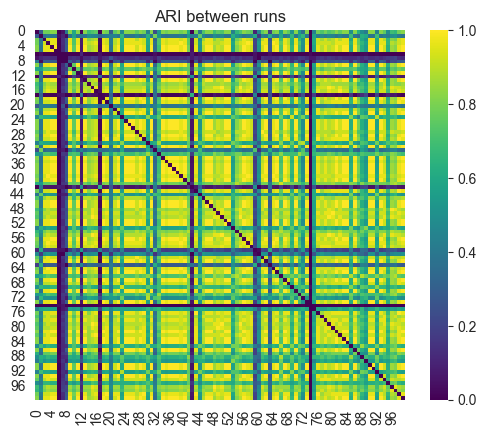

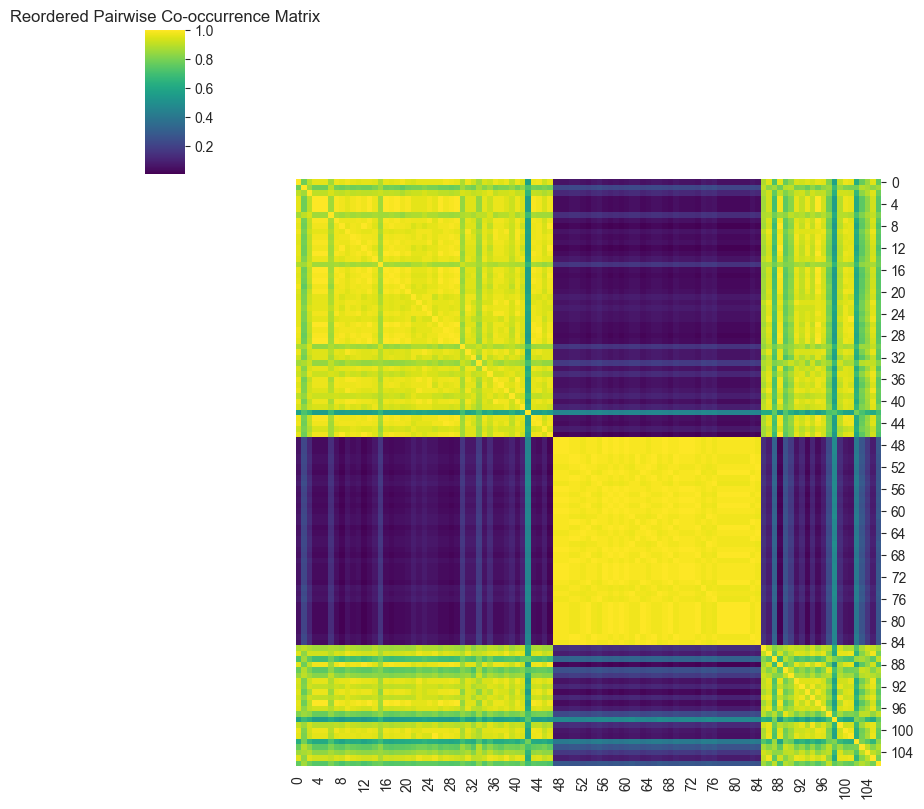

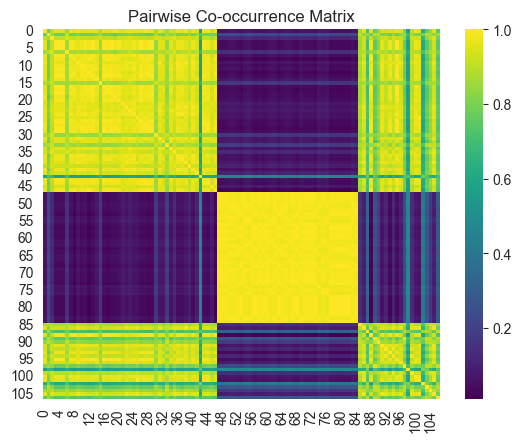

{'mean_ARI': np.float64(0.6797457786415166),
 'ARI_matrix': array([[0.        , 0.27725338, 0.78434429, ..., 0.6565049 , 0.78434429,
         0.81823828],
        [0.27725338, 0.        , 0.36316977, ..., 0.5133462 , 0.41042074,
         0.38645751],
        [0.78434429, 0.36316977, 0.        , ..., 0.78587301, 0.92562751,
         0.96243377],
        ...,
        [0.6565049 , 0.5133462 , 0.78587301, ..., 0.        , 0.85442191,
         0.81973785],
        [0.78434429, 0.41042074, 0.92562751, ..., 0.85442191, 0.        ,
         0.96243377],
        [0.81823828, 0.38645751, 0.96243377, ..., 0.81973785, 0.96243377,
         0.        ]]),
 'cooccurrence': array([[1.  , 0.78, 0.9 , ..., 0.85, 0.95, 0.76],
        [0.78, 1.  , 0.86, ..., 0.87, 0.83, 0.86],
        [0.9 , 0.86, 1.  , ..., 0.89, 0.95, 0.78],
        ...,
        [0.85, 0.87, 0.89, ..., 1.  , 0.9 , 0.85],
        [0.95, 0.83, 0.95, ..., 0.9 , 1.  , 0.79],
        [0.76, 0.86, 0.78, ..., 0.85, 0.79, 1.  ]]),
 'mean_cooccu

In [49]:
compute_stability(X, 2)